# Complexity analysis through time

During our first analysis of the shadowing phenomena over pip environment, we noticed an increasing linear pattern of such phenomena over time (from 2016 to 2025). Starting from this result, we decide to investigate if this linear growing is linked in some way with an increasing of the package complexity (e.g. LOC, cyclomatic complexity, nesting depth, total number of dependencies and the depth of dependency tree)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

In [5]:
DATA_PATH = "../../data/complexity/test.csv"

df  = pd.read_csv(DATA_PATH)

df.dropna(inplace=True)

df

,package,file,year,loc,cyclomatic_complexity,max_scope_nesting_level,total_dependencies,max_dependencies_depth
0,djhtml,./djhtml/options.py,2025,85,-1,2,1,1
1,djhtml,./djhtml/__init__.py,2025,0,-1,1,1,1
2,djhtml,./djhtml/tokens.py,2025,70,1,4,1,1
3,djhtml,./djhtml/modes.py,2025,657,258,4,1,1
4,djhtml,./djhtml/lines.py,2025,84,35,4,1,1
...,...,...,...,...,...,...,...,...
180,pycrunchbase,./pycrunchbase/resource/video.py,2016,26,5,3,3,2
181,pycrunchbase,./pycrunchbase/resource/image.py,2016,26,5,3,3,2
182,pycrunchbase,./pycrunchbase/resource/news.py,2016,33,11,3,3,2
183,pycrunchbase,./pycrunchbase/resource/category.py,2016,27,5,3,3,2


In [15]:
# wrangling dataframe to have it package-wise
df_packages = df.groupby(["year", "package"]).agg(
    loc = ("loc", "sum"),
    cyclomatic_complexity = ("cyclomatic_complexity", "sum"),
    max_scope_nesting_level = ("max_scope_nesting_level", "mean"),
    total_dependencies = ("total_dependencies", "max"),
    max_dependencies_depth = ("max_dependencies_depth", "max")
)

df_packages

loc  cyclomatic_complexity  max_scope_nesting_level  \
year package                                                                   
2016 geolinks            110                     27                 2.000000   
     pycrunchbase       1482                    425                 2.923077   
2019 diffios             525                    176                 2.500000   
     taretto              23                      0                 1.500000   
2020 pyhardlinkbackup   4405                    764                 2.583333   
     pywapfetion         263                     90                 3.200000   
2021 authclient           21                      8                 2.000000   
2022 formish            6574                    762                 2.062500   
     zconfig           11392                   2850                 2.982143   
2025 djhtml             1092                    349                 3.000000   

                       total_dependencies  max_dependencies_depth  
year package                                                       
2016 geolinks                           1                       1  
     pycrunchbase                       3                       2  
2019 diffios                            1                       1  
     taretto                           14                       6  
2020 pyhardlinkbackup                  22                       5  
     pywapfetion                        1                       1  
2021 authclient                        10                       4  
2022 formish                           11                       4  
     zconfig                            1                       1  
2025 djhtml                             1                       1

In [24]:
def draw_complexity_stats(x, x_label, y, y_label, title):
    # TODO: migliorare aspetto grafico usando seaborn (dare una volta trovato miglior grafico possibile)
    plt.scatter(x, y)

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()

df_packages_plot = df_packages.reset_index() # reset the index to be able to plot it easily using year as x-axis

x_axis = df_packages_plot.loc[:, "year"]
y_loc_axis = df_packages_plot.loc[:, "loc"]
y_cc_axis = df_packages_plot.loc[:, "cyclomatic_complexity"]
y_scope_nesting_axis = df_packages_plot.loc[:, "max_scope_nesting_level"]
y_tot_deps_axis = df_packages_plot.loc[:, "total_dependencies"]
y_deptree_depth_axis = df_packages_plot.loc[:, "max_dependencies_depth"]

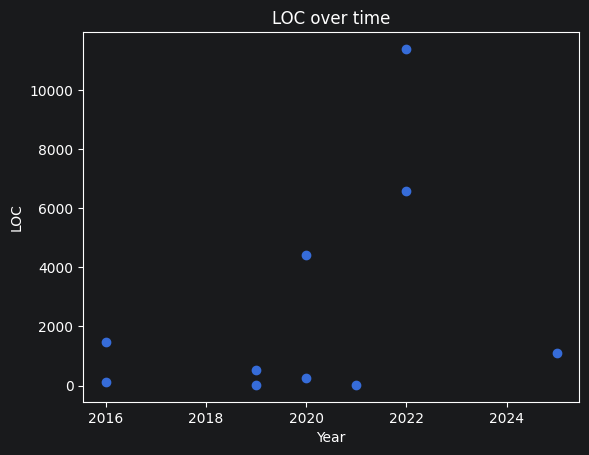

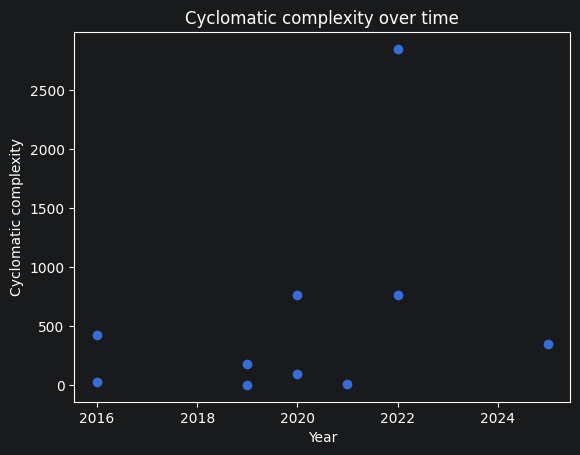

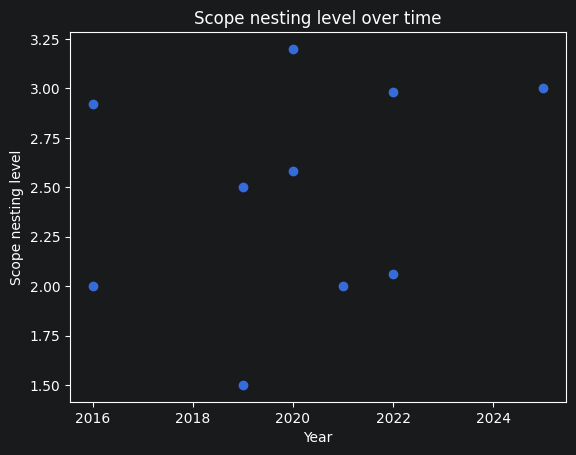

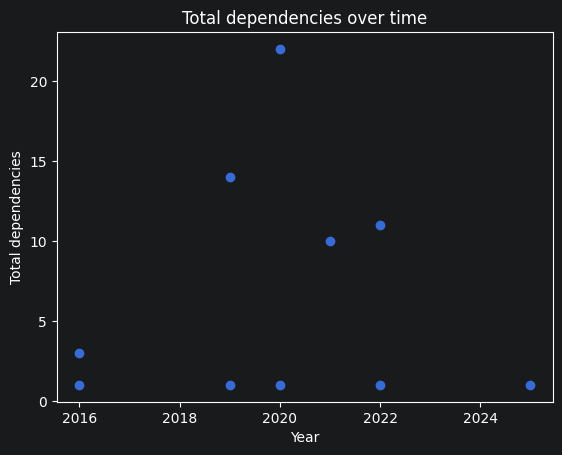

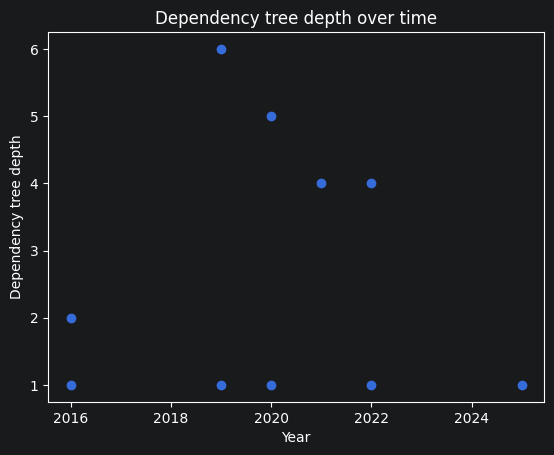

In [27]:
draw_complexity_stats(x_axis, "Year", y_loc_axis, "LOC", "LOC over time")
draw_complexity_stats(x_axis, "Year", y_cc_axis, "Cyclomatic complexity", "Cyclomatic complexity over time")
draw_complexity_stats(x_axis, "Year", y_scope_nesting_axis, "Scope nesting level", "Scope nesting level over time")
draw_complexity_stats(x_axis, "Year", y_tot_deps_axis, "Total dependencies", "Total dependencies over time")
draw_complexity_stats(x_axis, "Year", y_deptree_depth_axis, "Dependency tree depth", "Dependency tree depth over time")